In [1]:
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
import json
import numpy as np
import matplotlib.pyplot as plt
import sat_utils as su
import importlib
from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import baseband_utils as butils
importlib.reload(su)

BDC is using numpy
BDC is using numpy


<module 'sat_utils' from '/home/thomasb/albatros_analysis/scripts/orbcomm/sat_utils.py'>

Testing some funcitons for summer 2025 data using functions I made, which are stored in sat_utils and baseband_utils

# 1. Simultaneous Data

In [2]:
#all the antenna we want to look at
ant_path_list =['/scratch/mohanagr/summer_2025/baseband/mars1',
                '/scratch/mohanagr/summer_2025/baseband/mars2',
                '/scratch/mohanagr/summer_2025/baseband/mars3',
                '/scratch/mohanagr/summer_2025/baseband/mars4',
                '/scratch/mohanagr/summer_2025/baseband/mars5',
                '/scratch/mohanagr/summer_2025/baseband/mars6',
                '/scratch/mohanagr/summer_2025/baseband/mars7',
                '/scratch/mohanagr/summer_2025/baseband/mars8']

#big interval to catch everything
interval_start, interval_end = 1753100000, 1753400000

mars1
mars2
mars3
mars4
mars5
mars6
mars7
mars8
raw file ant mars1 ['/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113700.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113753.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113807.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113861.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113915.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113969.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114022.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114075.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114128.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114183.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114237.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114289.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114345.raw', '/scratch/mohanagr/summer_2025/base

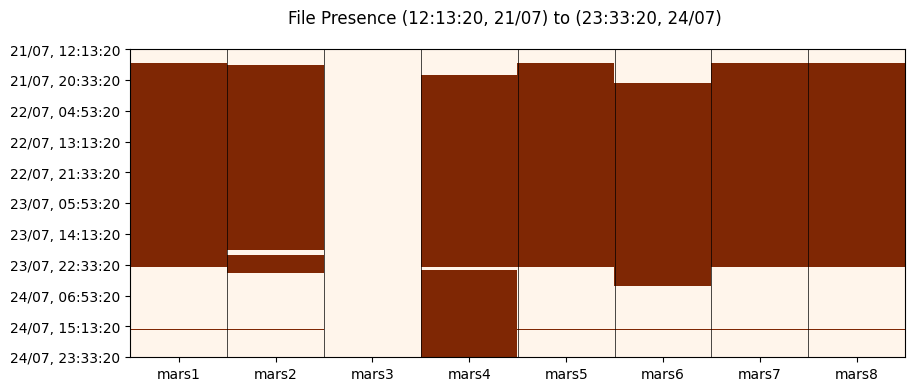

In [5]:
#get_present_files returns an array that tells you when files are present
arr, fig1 = butils.get_present_files(interval_start, interval_end, ant_path_list)

In [4]:
#runs give you timestamps within which there is active data from every desired antenna
runs = butils.get_simul_files(arr, 1753100000, 10, [0, 1, 3, 4, 5, 6, 7])
print(runs)

[[1753132820, 1753200010], [1753200150, 1753286400], [1753286530, 1753296030], [1753300680, 1753311920], [1753372970, 1753373350]]


Each of these timestamp intervals is called a 'batch'. We run satdet for each batch individually, since spectra reset between days (so beteween most batches).

# 2. Single Batch Map

Once we have satdet, we can map SNR against time for any batch we want. We take a small snippet as an example.

In [28]:
#define some paths and a cutoff
path1 = '/scratch/thomasb/satdet_data_1753132820_1M_len_7180_1769193967.json'
start1 = 1753132820
end1 = 1753132820 + 8000
ant_name = 'Antenna 2'

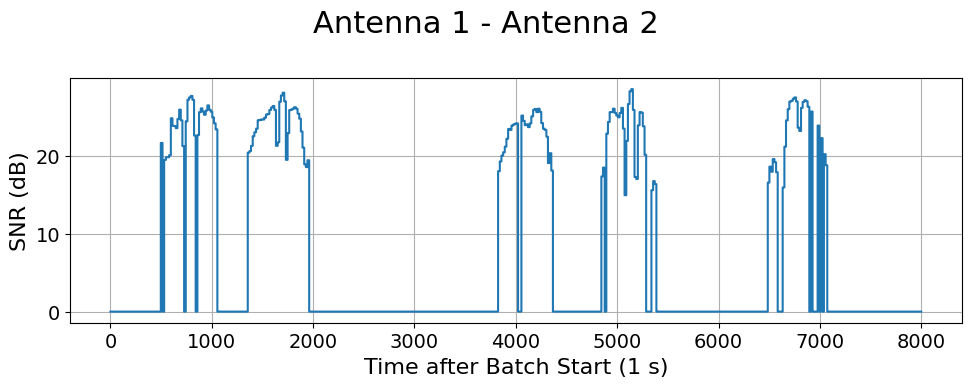

In [29]:
importlib.reload(su)
time_arr, snr_arr, fig2 = su.snr_times_single(path1, start1, end1, ant_name)

# 3. Overlapping Batch Map

If we want to compare two batches, we can plot two batches on top of each other. This function automatically lines up the axes so that horizontal lines coincide with LST to the nearest second. The x axis tick marks are zero for the individual batch's start time.

In [30]:
#define a second path
path2 = '/scratch/thomasb/satdet_data_1753200150_3M_len_6000_1769192936.json'
start2 = 1753200150
end2 = 1753200150 + 6000

start lsts [169.20739175867078, 90.51715899442962]
min lst 90.51715899442962
Front padding triggered at 18885
max array len 26886
pad 0
pad 20885


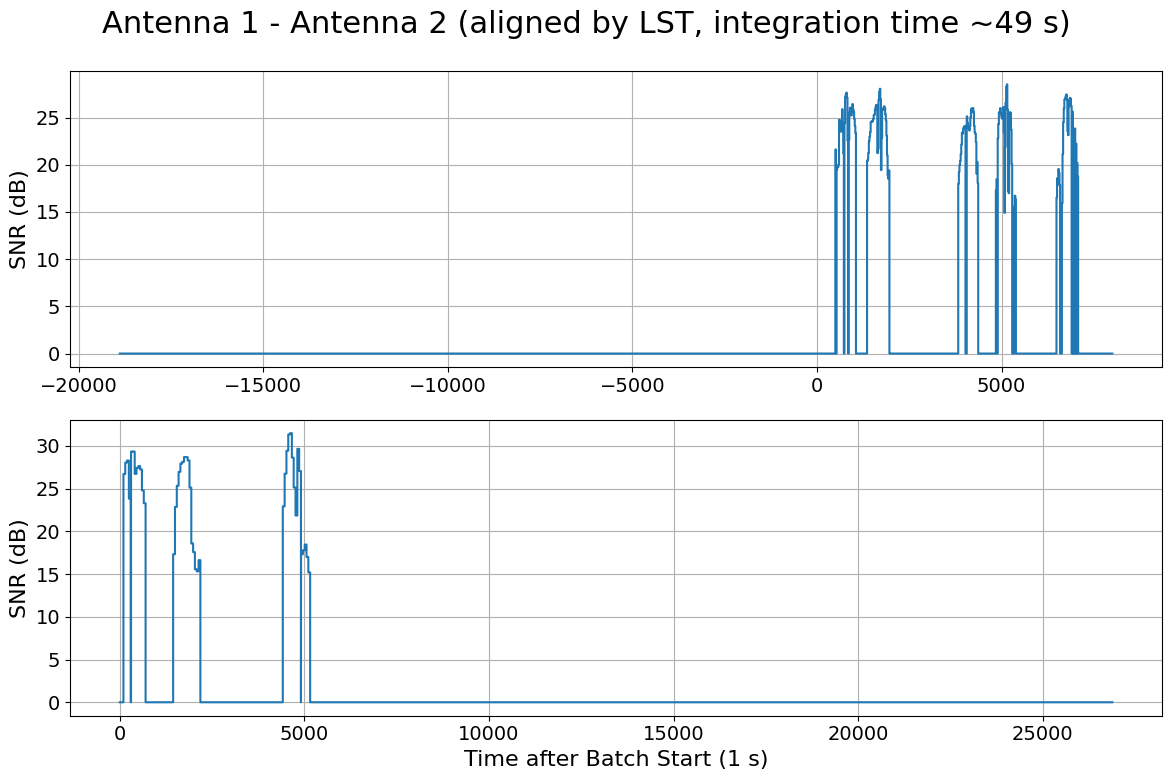

In [31]:
secs, times, fig3 = su.snr_times_many([path1, path2], [start1, start2], [end1, end2], ant_name)

So in this example, the pulses do not overlap in LST. 

# 4. Two Full Batches

In [3]:
bpath1 = '/scratch/thomasb/satdet_data_1753132820_3M_len_67200_1769207603.json'
bstart1 = 1753132820
bend1 = 1753132820 + 67200

bpath2 = '/scratch/thomasb/satdet_data_1753200150_3M_len_86260_1769307199.json'
bstart2 = 1753200150
bend2 = 1753286400

bpath3 = '/scratch/thomasb/satdet_data_1753286530_3M_len_9500_1769554690.json'
bstart3 = 1753286530
bend3 = 1753286530 + 9500

bpath4 = '/scratch/thomasb/satdet_data_1753300680_3M_len_11240_1769554685.json'
bstart4 = 1753300680
bend4 = 1753300680 + 11240

ant_name = 'Antenna 2'

start lsts [169.20739175867078, 90.51715899442962, 91.41924829499285, 150.53900473424972]
min lst 90.51715899442962
Front padding triggered at 18885
Front padding triggered at 216
Front padding triggered at 14405
max array len 86251
pad 165
pad 0
pad 76534
pad 60605


/home/thomasb/albatros_analysis/scripts/orbcomm/sat_utils.py:387: RuntimeWarning: divide by zero encountered in log10
  snr_db = np.where(snrarr > 0, 10 * np.log10(snrarr), 0.0)


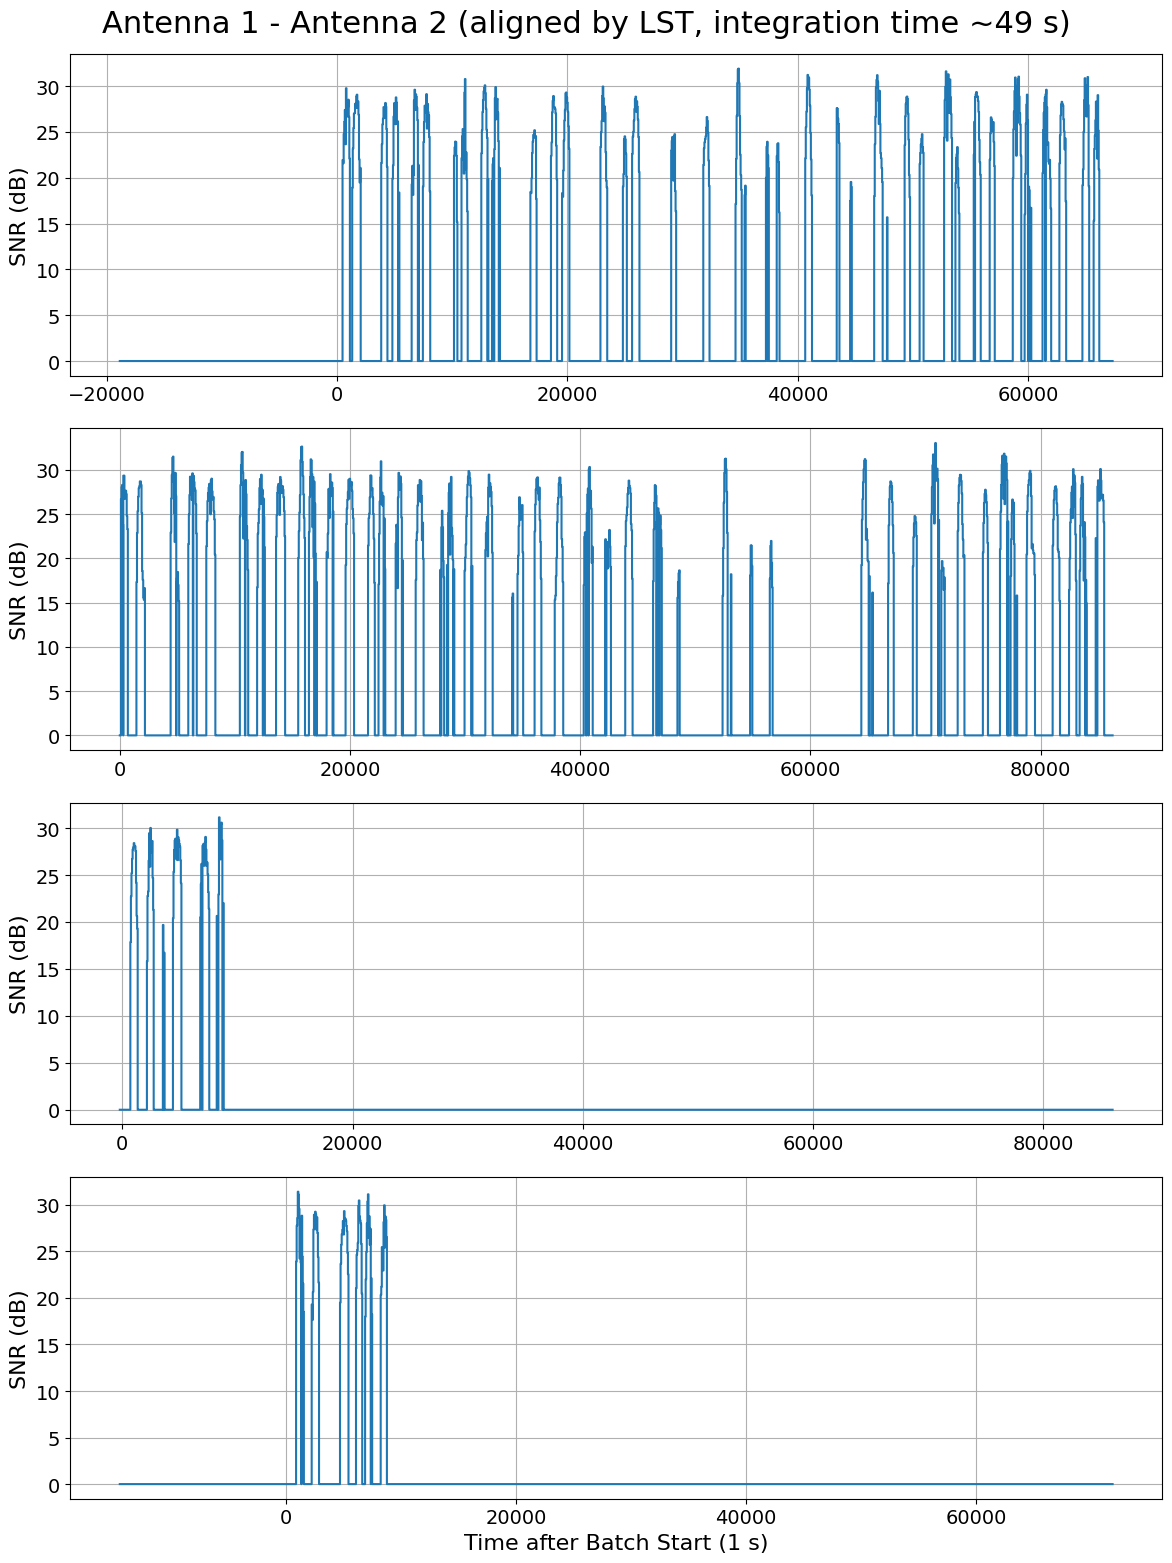

In [11]:
importlib.reload(su)
bsecs, btimes, fig4 = su.snr_times_many(
    [bpath1, bpath2, bpath3, bpath4], 
    [bstart1, bstart2, bstart3, bstart4], 
    [bend1, bend2, bend3, bend4], 
    ant_name)

In [5]:
def get_windows_oneant(json_path, 
                       batch_start, 
                       ant,
                       min_SNR,
                       min_nchunks,
                       max_nchunks=None,
                       interval=None
                       ):

    windows = []
    data = su.load_json(json_path)[f'{batch_start}']
    ant_data = data[ant]

    for pulse in ant_data:
        t0, t1 = pulse["times"]
        if interval is not None:
            int_start = batch_start + interval[0]
            int_end   = batch_start + interval[1]
            if t1<int_start or t0>int_end:
                continue

        chunks = pulse["SNR, Chan, Sat"]
        if not chunks:
            continue

        snrs  = np.array([c[0] for c in chunks])
        chans = np.array([c[1] for c in chunks])
        sats  = np.array([c[2] for c in chunks])

        nchunks = len(snrs)
        chunk_dt = (t1 - t0) / nchunks

        above = snrs > min_SNR

        # ---------------------------------------------
        # Find contiguous True segments
        # ---------------------------------------------
        segments = []
        start = None

        for i, flag in enumerate(above):
            if flag:
                if start is None:
                    start = i
            else:
                if start is not None:
                    segments.append((start, i))
                    start = None

        if start is not None:
            segments.append((start, len(above)))

        if not segments:
            continue

        best_global_mean = -np.inf
        best_start = None
        best_len = 0

        # ---------------------------------------------
        # Evaluate each segment
        # ---------------------------------------------
        for s, e in segments:
            seg_len = e - s

            if seg_len < min_nchunks:
                continue

            segment_snrs = snrs[s:e]

            # Case 1: no max limit → take whole segment
            if max_nchunks is None or seg_len <= max_nchunks:
                seg_mean = segment_snrs.mean()

                if seg_mean > best_global_mean:
                    best_global_mean = seg_mean
                    best_start = s
                    best_len = seg_len

            else:
                # Case 2: need best subwindow of length max_nchunks
                k = max_nchunks

                # cumulative sum for fast sliding mean
                csum = np.cumsum(segment_snrs)
                csum = np.insert(csum, 0, 0)

                # compute window sums
                window_sums = csum[k:] - csum[:-k]
                idx = np.argmax(window_sums)

                seg_mean = window_sums[idx] / k

                if seg_mean > best_global_mean:
                    best_global_mean = seg_mean
                    best_start = s + idx
                    best_len = k

        if best_start is None:
            continue
        end_idx = best_start + best_len

        t_start = int(t0 + best_start * chunk_dt)
        t_end = int(t0 + end_idx * chunk_dt)

        windows.append({
            "antenna": ant,
            "sat": int(sats[best_start]),
            "channel": int(chans[best_start]),
            "t_start": t_start,
            "t_end": t_end,
            "len": t_end - t_start
        })
    return windows


In [6]:
def get_joint_windows(json_path,
                      batch_start,
                      antennas,
                      min_SNR,
                      min_nchunks,
                      max_nchunks=None,
                      interval=None):
    """
    Compute overlapping windows across multiple antennas,
    including satID and channel information.

    Returns:
        List of dicts with t_start, t_end, sat, channel
    """

    # 1) Collect windows per antenna
    windows_by_ant = {}
    for ant in antennas:
        windows_by_ant[ant] = get_windows_oneant(
            json_path=json_path,
            batch_start=batch_start,
            ant=ant,
            min_SNR=min_SNR,
            min_nchunks=min_nchunks,
            max_nchunks=max_nchunks,
            interval=interval
        )

    ants = list(windows_by_ant.keys())
    if not ants:
        return []

    # Sort each antenna's windows by start time
    for ant in ants:
        windows_by_ant[ant] = sorted(
            windows_by_ant[ant],
            key=lambda w: w["t_start"]
        )

    # Initialize indices for each antenna
    indices = {ant: 0 for ant in ants}
    joint_overlaps = []

    while True:
        # Stop if any antenna is exhausted
        if any(indices[ant] >= len(windows_by_ant[ant]) for ant in ants):
            break

        current_windows = [
            windows_by_ant[ant][indices[ant]]
            for ant in ants
        ]

        # Compute intersection
        max_start = max(w["t_start"] for w in current_windows)
        min_end   = min(w["t_end"] for w in current_windows)

        if max_start < min_end:
            # Determine which antenna limits the overlap (earliest end)
            earliest_end_ant = min(
                ants,
                key=lambda ant: windows_by_ant[ant][indices[ant]]["t_end"]
            )
            limiting_window = windows_by_ant[earliest_end_ant][indices[earliest_end_ant]]

            joint_overlaps.append({
                "t_start": int(max_start),
                "t_end": int(min_end),
                "sat": int(limiting_window["sat"]),
                "channel": int(limiting_window["channel"]),
                "len": int(min_end) - int(max_start)
            })

        # Advance the antenna whose window ends earliest
        earliest_end_ant = min(
            ants,
            key=lambda ant: windows_by_ant[ant][indices[ant]]["t_end"]
        )
        indices[earliest_end_ant] += 1

    return joint_overlaps


In [9]:
w_all = get_windows_oneant(bpath2, 
                        bstart2, 
                        "Antenna 2",
                        400, #min SNR
                        4,  #min number of chunks
                        max_nchunks=None,
       #                 interval=[6e4, 9e4]  #seconds in batch time you can look at
                        )

print(len(w_all)) 
for p in w_all:
    print(p)

34
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753200455, 't_end': 1753200749, 'len': 294}
{'antenna': 'Antenna 2', 'sat': 33591, 'channel': 16, 't_start': 1753201742, 't_end': 1753202037, 'len': 295}
{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753204614, 't_end': 1753204859, 'len': 245}
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753206198, 't_end': 1753206493, 'len': 295}
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753206540, 't_end': 1753206785, 'len': 245}
{'antenna': 'Antenna 2', 'sat': 33591, 'channel': 16, 't_start': 1753208058, 't_end': 1753208303, 'len': 245}
{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753210629, 't_end': 1753210874, 'len': 245}
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753212276, 't_end': 1753212571, 'len': 295}
{'antenna': 'Antenna 2', 'sat': 33591, 'channel': 16, 't_start': 1753214069, 't_end': 1753214413, 'len': 344}
{'antenna': '

In [ ]:
#dump pulses

# DONT TOUCH IT WILL OVERWRITE PULSES

# path_pulses = '/scratch/thomasb/full_timing_discrepancies_1753200150/XXXXXX.json'
# with open(path_pulses, "w") as f:
#         json.dump(w_all, f, indent=2)

In [35]:
def get_MAD(data, axis=None):
    data_median = np.median(data, axis=axis, keepdims=True)
    abs_deviations = np.abs(data - data_median)
    mad = np.median(abs_deviations, axis=axis)
    return mad

In [ ]:
def get_prediction_error(res, spectra):

    A = np.column_stack((spectra, np.ones(len(spectra))))

    N = np.cov(res)
    print(N)
    #N2 = np.var(res)
    #print(N2)

    if res.ndim >1:
        v1 = np.linalg.inv(A.T@np.linalg.inv(N)@A)

    else:
        v1 = N*np.linalg.inv(A.T@A)

    return A@v1@A.T

In [37]:
#get mapping path for initial
path_mapping1 = f'/scratch/thomasb/full_timing_discrepancies_{bstart2}/times.json'
with open(path_mapping1, "r") as f:
        map1 = json.load(f)

In [38]:
#get mapping path incoherent_all
path_mapping2 = f'/scratch/thomasb/full_timing_discrepancies_{bstart2}/times_all_incoherent.json'
with open(path_mapping2, "r") as f:
        map2 = json.load(f)

In [43]:
utc_corr, spectra_uncorr = [], []

# for fname, pulse in map1.items():
#     utc_corr.append(pulse['offset_fitted']/1000 + pulse["pulse_start_ts"])
#     spectra_uncorr.append(pulse["start_spectrum"])

for fname, pulse in map2.items():
    utc_corr.append(pulse['offset_fitted']/1000 + pulse["pulse_start_ts"])
    spectra_uncorr.append(pulse["start_spectrum"])
utc_corr = utc_corr[1:]
spectra_uncorr = spectra_uncorr[1:]

In [44]:
overflow = False
spectra_corr = []
for i in range(len(spectra_uncorr)):
    if i>0:
        if abs(spectra_uncorr[i] - spectra_uncorr[i-1]) > 2**31:
            overflow = True
    if overflow:
        spectra_corr.append(spectra_uncorr[i]+2**32) 
    else:
        spectra_corr.append(spectra_uncorr[i])

spectra_corr = np.array(spectra_corr)
utc_corr = np.array(utc_corr)

Seconds per spectra 1.638400946109685e-05
Initial UTC time: 1753200128.469018


Text(0, 0.5, 'UTC Time (s)')

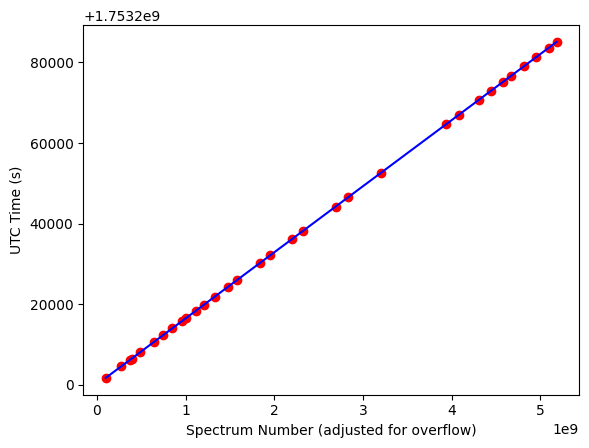

In [45]:
m,c = np.polyfit(spectra_corr, utc_corr, 1)
print('Seconds per spectra', m)
print('Initial UTC time:', c)
plt.scatter(spectra_corr, utc_corr, c='r')
plt.plot(spectra_corr, m*spectra_corr + c, c='b')
plt.xlabel('Spectrum Number (adjusted for overflow)')
plt.ylabel('UTC Time (s)')

In [53]:
mohan_spectrum = 1011109505
start_UTC = mohan_spectrum*m + c
print(start_UTC)

1753216694.496714


Standard deviation of residuals: 0.08431304320590603 secs
-0.06433892250061035


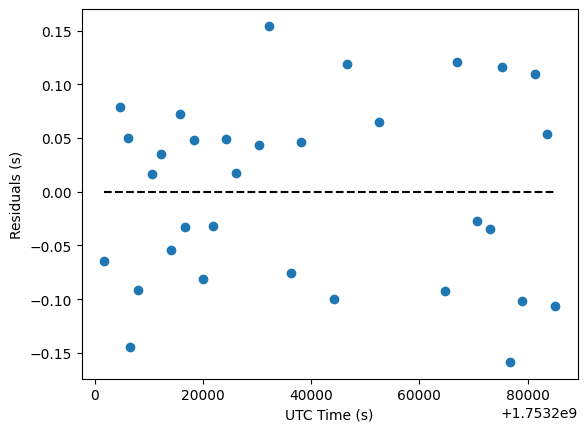

In [46]:
res = np.asarray(utc_corr)-m*np.asarray(spectra_corr)-c
plt.scatter(utc_corr, res)
plt.xlabel('UTC Time (s)')
plt.ylabel('Residuals (s)')
plt.hlines(y=0,xmin=np.min(utc_corr), xmax=np.max(utc_corr),color='black',linestyle='--')
print(f'Standard deviation of residuals: {np.std(res)} secs')

print(res[0])

In [47]:
res_MAD = get_MAD(res)
print(f"Residual MAD: {res_MAD}")

Residual MAD: 0.06636595726013184


In [51]:
cov = get_prediction_error(res, spectra_corr)

pred_var = np.diag(cov)
pred_error = np.sqrt(pred_var)
print(pred_error)
print('Error on UTC given a spectrum number:', np.mean(pred_error))

0.0073380018112422975
0.007108689254640976
[0.02532442 0.02408418 0.02341712 0.02327479 0.02265047 0.02162611
 0.02099284 0.02032566 0.01970767 0.01941975 0.01882585 0.01834979
 0.01776926 0.01710669 0.01668569 0.01585145 0.01558212 0.01521124
 0.0151477  0.01542717 0.01571901 0.01690545 0.02069665 0.02158321
 0.02307032 0.02402937 0.02499113 0.02564181 0.026671   0.02770037
 0.02878327 0.02945734]
Error on UTC given a spectrum number: 0.02100090276312941


In [1]:
# old way of doing it between two values
def get_error(ts1, ts2, s1, s2, o1, o2):
    T_SPECTRA = 4096/250e6
    t1_corr = ts1+o1
    t2_corr = ts2+o2
    time = t2_corr-t1_corr
    spec = s2-s1
    if abs(spec) > 2**31:
        spec += 2**32
    error = time - spec*T_SPECTRA
    return error

In [ ]:
tester =  np.array([[1, 0, 0, 0],
                    [1, 0, 0, 0],
                    [1, 0, 0, 0],
                    [1, 0, 0, 0]])

axis0 = np.sum(tester, axis = 0)
print(axis0)
axis1 = np.sum(tester, axis = 1)
print(axis1)

0
[4 0 0 0]
[1 1 1 1]
